In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split , GridSearchCV , KFold , cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler , OneHotEncoder , OrdinalEncoder 
from sklearn.base import BaseEstimator , TransformerMixin

In [2]:
df = pd.read_csv('data/Cleaned Delivery Dataset.csv')

In [3]:
pd.set_option('display.max_columns' , None)

In [4]:
df.drop(columns=['Delivery_Agent'] , inplace=True)

In [5]:
df['Order_Datetime'] = pd.to_datetime(df['Order_Datetime'])
df['Pickup_Datetime'] = pd.to_datetime(df['Pickup_Datetime'])

In [6]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius (km)

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [7]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self.rating_bins = None

    def fit(self, X, y=None):
        X = X.copy()
        
        # Store bins for consistent transformation
        self.rating_bins = pd.qcut(
            X['Delivery_person_Ratings'],
            q=3,
            retbins=True,
            duplicates='drop'
        )[1]
        
        return self

    def transform(self, X):
        X = X.copy()

        # Datetime conversion
        X['Order_Datetime'] = pd.to_datetime(X['Order_Datetime'], errors='coerce')
        X['Pickup_Datetime'] = pd.to_datetime(X['Pickup_Datetime'], errors='coerce')

        # Distance
        X["distance_km"] = haversine(
            X["Restaurant_latitude"],
            X["Restaurant_longitude"],
            X["Delivery_location_latitude"],
            X["Delivery_location_longitude"]
        )

        # Rating group
        X["delivery_rating_group"] = pd.cut(
            X['Delivery_person_Ratings'],
            bins=self.rating_bins,
            labels=['Low', 'Medium', 'High'],
            include_lowest=True
        )

        # Age group
        X["age_group"] = pd.cut(
            X['Delivery_person_Age'],
            bins=[14, 25, 35, 60],
            labels=['Young', 'Adult', 'Senior']
        )

        # Distance group
        X["distance_group"] = pd.cut(
            X['distance_km'],
            bins=[0, 5, 10, 25],
            labels=['Short Distance', 'Medium Distance', 'Long Distance']
        )

        # Time features
        X['Prep_Time(min)'] = (
            X['Pickup_Datetime'] - X['Order_Datetime']
        ).dt.total_seconds() / 60

        X['Order_hour'] = X['Order_Datetime'].dt.hour
        X['Order_day'] = X['Order_Datetime'].dt.day_name()

        X['isWeekend'] = X['Order_day'].isin(["Saturday", "Sunday"]).astype(int)

        X['Time_Of_Day'] = pd.cut(
            X['Order_hour'],
            bins=[0, 6, 12, 18, 24],
            labels=["Night", "Morning", "Afternoon", "Evening"],
            include_lowest=True
        )

        # Drop raw datetime
        X = X.drop(columns=['Order_Datetime', 'Pickup_Datetime'], errors='ignore')

        return X

    def get_feature_names_out(self , input_features = None):
        return input_features

In [8]:
X = df.drop(columns=['Time_taken (min)'])
y = df['Time_taken (min)']

In [9]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [10]:
X

,City,Zone,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Datetime,Pickup_Datetime,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_Type
0,Dehradun,Zone17,36,4.2,30.327968,78.046106,30.397968,78.116106,2022-12-02 21:55:00,2022-12-02 22:10:00,Fog,Jam,Good,Snack,motorcycle,3,No,Metropolitian
1,Kochi,Zone16,21,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13 14:55:00,2022-02-13 15:05:00,Stormy,High,Average,Meal,motorcycle,1,No,Metropolitian
2,Pune,Zone13,23,4.7,18.562450,73.916619,18.652450,74.006619,2022-04-03 17:30:00,2022-04-03 17:40:00,Sandstorms,Medium,Average,Drinks,scooter,1,No,Metropolitian
3,Ludhiana,Zone15,34,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13 09:20:00,2022-02-13 09:30:00,Sandstorms,Low,poor,Buffet,motorcycle,0,No,Metropolitian
4,Kanpur,Zone14,24,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14 19:50:00,2022-02-14 20:05:00,Fog,Jam,Average,Snack,scooter,1,No,Metropolitian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39637,Bangalore,Zone16,28,4.9,13.029198,77.570997,13.059198,77.600997,2022-03-30 21:55:00,2022-03-30 22:05:00,Sandstorms,Jam,Average,Meal,scooter,1,No,Metropolitian
39638,Ranchi,Zone16,35,4.2,23.371292,85.327872,23.481292,85.437872,2022-08-03 21:45:00,2022-08-03 21:55:00,Windy,Jam,Good,Drinks,motorcycle,1,No,Metropolitian
39639,Chennai,Zone08,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-11-03 23:50:00,2022-11-04 00:05:00,Cloudy,Low,Average,Drinks,scooter,0,No,Metropolitian
39640,Coimbatore,Zone11,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-07-03 13:35:00,2022-07-03 13:40:00,Cloudy,High,poor,Snack,motorcycle,1,No,Metropolitian


In [11]:
numerical = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 
       'multiple_deliveries', 'distance_km', 'Prep_Time(min)', 'Order_hour',
       'isWeekend']

ohe_col = ['City', 'Zone', 'Weather_conditions',
       'Type_of_order', 'Type_of_vehicle',
       'City_Type','Order_day', 'Time_Of_Day']

ordinal_col = ['Road_traffic_density' , 'Vehicle_condition' , 'Festival',
       'delivery_rating_group' , 'age_group' , 'distance_group']

In [12]:
transformer = ColumnTransformer(
    transformers=[
        ("ohe" , OneHotEncoder(sparse_output=False , handle_unknown='ignore') , ohe_col),
        ('oe' , OrdinalEncoder(categories=[
            ['Low', 'Medium', 'High', 'Jam'],                         # Road_traffic_density
            ['poor', 'Average', 'Good' , 'Excellent'],                # Vehicle_condition
            ['No', 'Yes'],                                            # Festival
            ['Low', 'Medium', 'High'],                                # delivery_rating_group
            ['Young', 'Adult', 'Senior'],                             # age_group
            ['Short Distance', 'Medium Distance', 'Long Distance']    # distance_group
        ]) , ordinal_col),
        ('Scaling' , StandardScaler() , numerical)
    ],remainder='passthrough'
)

In [13]:
pipeline = Pipeline(
    [
        ("FeatureEngineering" , FeatureEngineering()),
        ("ColumnTransformer" , transformer)
    ]
) 

In [14]:
X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

In [15]:
def cross_val_calculator(model):
    kfold = KFold(n_splits=10 , shuffle=True , random_state=42)

    score = cross_val_score(model , X_train , y_train , cv=kfold)

    print("\n")
    print("score = \n" , score)
    print("\n")
    print('mean_cross_val = ' , score.mean())
    print('std_cross_val = ' , score.std())

In [16]:
lr = LinearRegression()
lr.fit(X_train , y_train)

y_pred = lr.predict(X_test)

print("r2_score" , r2_score(y_test , y_pred))

cross_val_calculator(lr)

r2_score 0.6114430249708527


score = 
 [0.61795029 0.63059984 0.61221854 0.60338013 0.61791063 0.60523978
 0.62044028 0.62139245 0.62496023 0.59460109]


mean_cross_val =  0.6148693261625069
std_cross_val =  0.01041230723733673


In [17]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train , y_train)

y_pred = rf.predict(X_test)

print("r2_score" , r2_score(y_test , y_pred))

print("\n")

cross_val_calculator(rf)

r2_score 0.8227406754427861




score = 
 [0.81583686 0.82062177 0.8271558  0.81983964 0.83173925 0.82333284
 0.82706414 0.82171066 0.81872331 0.81269261]


mean_cross_val =  0.8218716888222873
std_cross_val =  0.005391581124505855


In [18]:
xgbr = XGBRegressor()
xgbr.fit(X_train , y_train)

y_pred = xgbr.predict(X_test)

print("r2_score" , r2_score(y_test , y_pred))

cross_val_calculator(xgbr)

r2_score 0.8199557662010193


score = 
 [0.81520265 0.81689727 0.82157469 0.81516391 0.82400048 0.82008576
 0.82322615 0.8259896  0.81698537 0.80632478]


mean_cross_val =  0.8185450673103333
std_cross_val =  0.00543815050494395


In [19]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , BatchNormalization , Dropout , Input 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau

C:\Users\LeoML\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [20]:
model = Sequential(
    [
        Input(shape=(X_train.shape[1],)),
        Dense(256 , activation='relu' , kernel_initializer='he_normal' , kernel_regularizer=l2(0.01)),
        Dropout(0.2),
        BatchNormalization(),
        Dense(128 , activation='relu' , kernel_initializer='he_normal', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        BatchNormalization(),
        Dense(64 , activation='relu' , kernel_initializer='he_normal' , kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        BatchNormalization(),
        Dense(1 , activation='linear')
    ]
)

In [21]:
optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer , loss='mse' , metrics=['r2_score'])

In [22]:
early_stopping = EarlyStopping(
    monitor='val_r2_score',
    min_delta=0.001,
    patience=20,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.05,
    patience=20,
    min_lr=1e-6
)

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split = 0.2, 
    callbacks=[early_stopping , lr_scheduler],    
)

Epoch 1/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 743.7581 - r2_score: -7.5579 - val_loss: 726.4657 - val_r2_score: -7.2929 - learning_rate: 1.0000e-04
Epoch 2/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 638.6233 - r2_score: -6.3355 - val_loss: 607.9316 - val_r2_score: -5.9249 - learning_rate: 1.0000e-04
Epoch 3/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 500.4541 - r2_score: -4.7280 - val_loss: 456.0737 - val_r2_score: -4.1715 - learning_rate: 1.0000e-04
Epoch 4/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 347.5818 - r2_score: -2.9490 - val_loss: 300.6315 - val_r2_score: -2.3764 - learning_rate: 1.0000e-04
Epoch 5/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 214.6950 - r2_score: -1.4024 - val_loss: 173.0727 - val_r2_score: -0.9033 - learning_rate: 1.0000e-04
Epoch 6/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 121.6100 - r2_score: -0.3193 - val_loss: 97.1097 - val_r2_score: -0.0263 - learning_rate: 1.0000e-04
Epoch 7/100
793/793 ━━

In [24]:
train_eval = model.evaluate(X_train , y_train)

test_eval = model.evaluate(X_test , y_test)

print("train_eval : " , train_eval)
print("test_eval : " , test_eval)

992/992 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 17.3811 - r2_score: 0.8371
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - loss: 20.6518 - r2_score: 0.7971
train_eval :  [17.381074905395508, 0.8371050357818604]
test_eval :  [20.651836395263672, 0.7970656752586365]


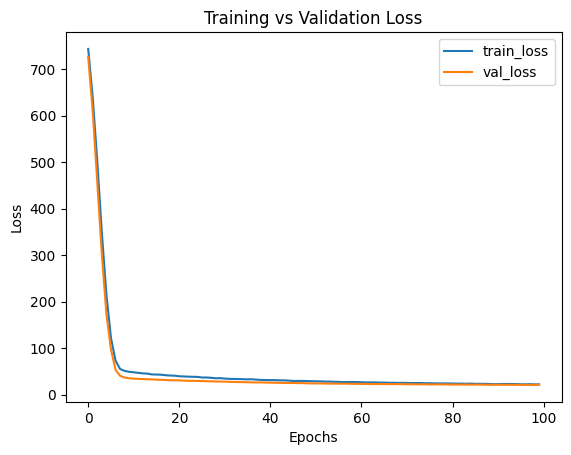

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'] , label = 'train_loss')
plt.plot(history.history['val_loss'] , label = 'val_loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

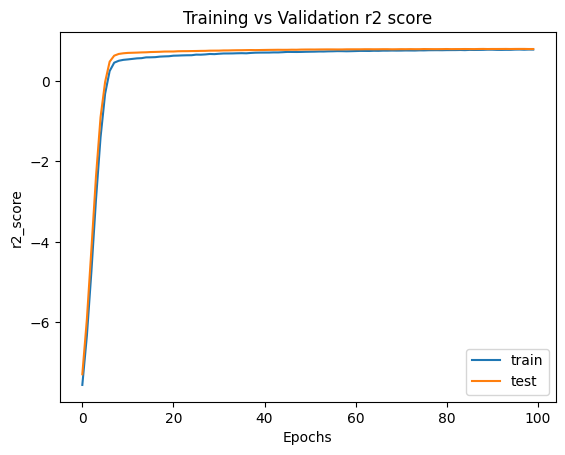

In [26]:
plt.plot(history.history['r2_score'] , label = 'train')
plt.plot(history.history['val_r2_score'] , label = 'test')

plt.xlabel('Epochs')
plt.ylabel('r2_score')
plt.title('Training vs Validation r2 score')
plt.legend()
plt.show()

## **Hyperparameter Tuning**

In [28]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0]
}

search = GridSearchCV(xgbr , param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=True)
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV R2 score:", search.best_score_)

best_model = search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print("Test R2 score:", r2_score(y_test, y_pred_tuned))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 1.0}
Best CV R2 score: 0.8262223800023397
Test R2 score: 0.8311833143234253


In [33]:
search.best_params_

{'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 1.0}